In [21]:
import mysql.connector
from mysql.connector import errorcode
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
config = {    
  'user': 'root',
  'password': '*',  
  'host': 'localhost',
  'database': 'basketball_stats'
}

DB_NAME = 'basketball_stats' 

print("Connection parameters defined.")

Connection parameters defined.


In [3]:
try:
    
    cnxn = mysql.connector.connect(**config)
    cursor = cnxn.cursor()
    print("✅ Connected to basketball_stats database.")


    # cnxn.commit()
    # print("✅ SQL script executed successfully.")

except mysql.connector.Error as err:
    print(f"❌ Connection or execution error: {err}")

finally:
    if 'cnxn' in locals() and cnxn.is_connected():
        cursor.close()
        cnxn.close()
        print("✅ Connection closed.")

✅ Connected to basketball_stats database.
✅ Connection closed.


فرضیه اول


<ul dir="rtl" style="font-family: vazir; font-size: medium; line-height: 200%; text-align: justify;">
  <li><strong>فرضیه صفر (H<sub>0</sub>):</strong> میانگین چابکی بازیکنان برتر در دوره جدید تفاوتی با گذشته ندارد </li>
  <li><strong>فرضیه جایگزین (H<sub>1</sub>):</strong>میانگین چابکی بازیکنان برتر در دوره جدید بیشتر از گذشته است</li>
</ul>

In [68]:
#فرضیه اول
try:
    
    with mysql.connector.connect(**config) as cnxn:
        query_past = """

        select
            ps.season,
            p.player_id,
            p.player_name,
            ps.rank,
            (p.height_cm / p.weight_kg) as agility,
            'Past' as group_lable
        from player_stats ps
        join players p on p.player_id = ps.player_id
        where ps.season in (2020, 2021) and ps.rank <= 20
            """

        query_new = """

        select
            ps.season,
            p.player_id,
            p.player_name,
            ps.rank,
            (p.height_cm / p.weight_kg) as agility,
            'New' as group_lable
        from player_stats ps
        join players p on p.player_id = ps.player_id
        where ps.season in (2022, 2023) and ps.rank <= 20;

            """
        df_past = pd.read_sql(query_past, cnxn)
        df_new = pd.read_sql(query_new, cnxn)
        
        # df_past["group_lable"] = "Past"
        # df_new["group_lable"] = "New"
        display(df_past)
        display(df_new)
        
        dft1 = pd.concat([df_past, df_new], ignore_index=True)
        # display(dft1)

except mysql.connector.Error as err:
    print(f"❌ Error: {err}")


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_7520\2128032191.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_past = pd.read_sql(query_past, cnxn)
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_7520\2128032191.py:34: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_new = pd.read_sql(query_new, cnxn)


,season,player_id,player_name,rank,agility,group_lable
0,2020,antetgi01,giannis antetokounmpo,4,1.918182,Past
1,2020,bealbr01,bradley beal,7,2.053191,Past
2,2020,bookede01,devin booker,3,2.129032,Past
3,2020,davisan02,anthony davis,10,1.808696,Past
4,2020,derozde01,demar derozan,16,1.980000,Past
5,2020,doncilu01,luka donÃ¤ÂiÃ¤Â,6,1.903846,Past
6,2020,hardeja01,james harden,1,1.960000,Past
7,2020,harrito02,tobias harris,19,1.990196,Past
8,2020,hieldbu01,buddy hield,20,1.930000,Past
9,2020,ingrabr01,brandon ingram,17,2.360465,Past


,season,player_id,player_name,rank,agility,group_lable
0,2022,antetgi01,giannis antetokounmpo,6,1.918182,New
1,2022,ballla01,lamelo ball,20,2.451220,New
2,2022,bookede01,devin booker,8,2.129032,New
3,2022,bridgmi02,miles bridges,15,1.970588,New
4,2022,brownja02,jaylen brown,17,1.960396,New
5,2022,curryst01,stephen curry,14,2.238095,New
6,2022,derozde01,demar derozan,2,1.980000,New
7,2022,doncilu01,luka donÃ¤ÂiÃ¤Â,7,1.903846,New
8,2022,duranke01,kevin durant,12,1.935780,New
9,2022,edwaran01,anthony edwards,19,1.892157,New


c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


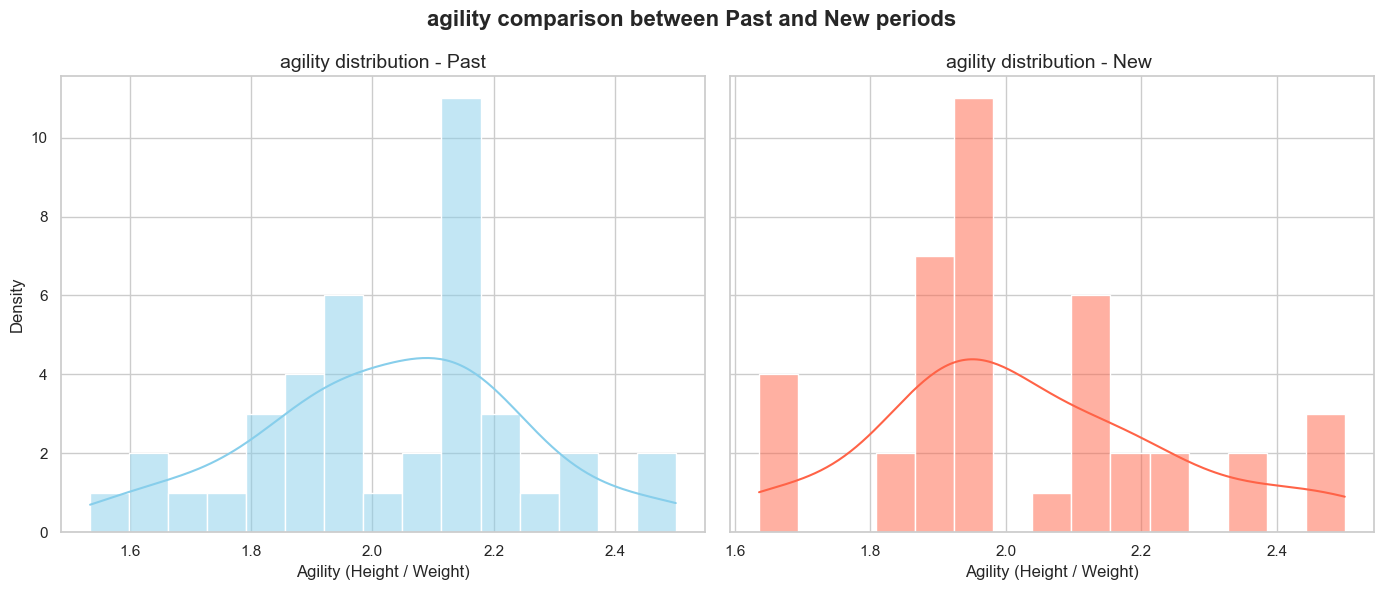

In [69]:
# هیستوگرام

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.histplot( data=df_past, x="agility", bins=15, kde=True, color="skyblue", ax=axes[0])
axes[0].set_title("agility distribution - Past", fontsize=14)
axes[0].set_xlabel("Agility (Height / Weight)")
axes[0].set_ylabel("Density")

sns.histplot( data=df_new, x="agility", bins=15, kde=True,color="tomato", ax=axes[1])
axes[1].set_title("agility distribution - New ", fontsize=14)
axes[1].set_xlabel("Agility (Height / Weight)")
axes[1].set_ylabel("Density")

plt.suptitle("agility comparison between Past and New periods", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldc

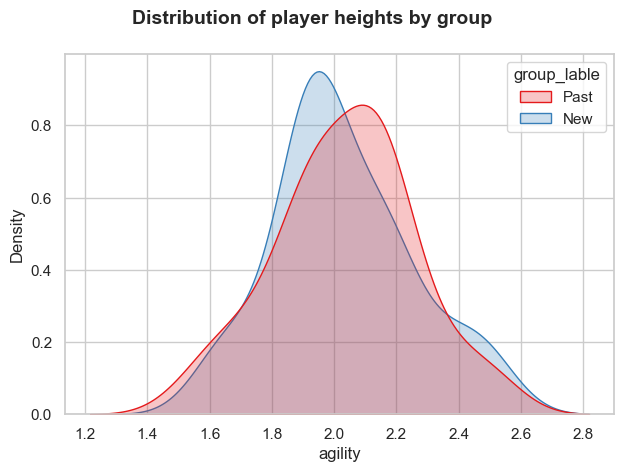

In [70]:
#kde
sns.kdeplot(data=dft1, x="agility", hue= "group_lable", palette="Set1",  fill=True)

plt.suptitle("Distribution of player heights by group", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [ ]:

shapiro_past = stats.shapiro(df_past['agility'])
print(f"shapiro test (Past):")
print(f"statistic = {shapiro_past.statistic:.3f}, p-value = {shapiro_past.pvalue:.3f}")

shapiro_new = stats.shapiro(df_new['agility'])
print(f"shapiro test (New):")
print(f"statistic = {shapiro_new.statistic:.3f}, p-value = {shapiro_new.pvalue:.3f}")

shapiro test (Past):
statistic = 0.976, p-value = 0.539
shapiro test (New):
statistic = 0.945, p-value = 0.050


In [72]:
#yeo_johnson

def Yeo_johnson(df, column_name, label):
  
    transformed_data, lambda_val = stats.yeojohnson(df[column_name])
    
    stat, p_value = stats.shapiro(transformed_data)
    print(f"Yeo-Johnson transformation for {label}:")
    print(f"λ = {lambda_val:.3f}, shapiro p-value = {p_value:.3f}")
    
    fig, ax = plt.subplots(figsize=(8, 6))
    stats.probplot(transformed_data, dist="norm", plot=ax)
    ax.set_title(f'QQ Plot for "{label}" after Yeo-Johnson\nshapiro p = {p_value:.3f}')
    plt.tight_layout()
    plt.show()
    
    return transformed_data




Yeo-Johnson transformation for Past:
λ = 1.414, shapiro p-value = 0.547


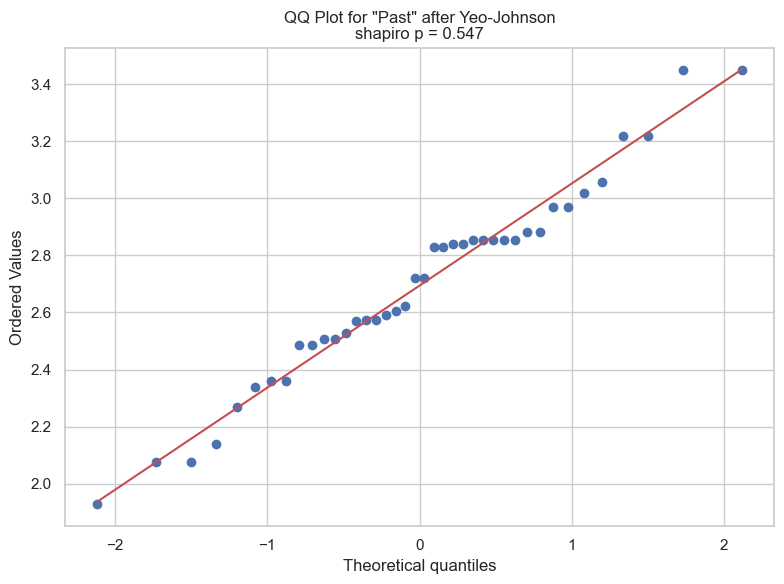

Yeo-Johnson transformation for New:
λ = -1.131, shapiro p-value = 0.097


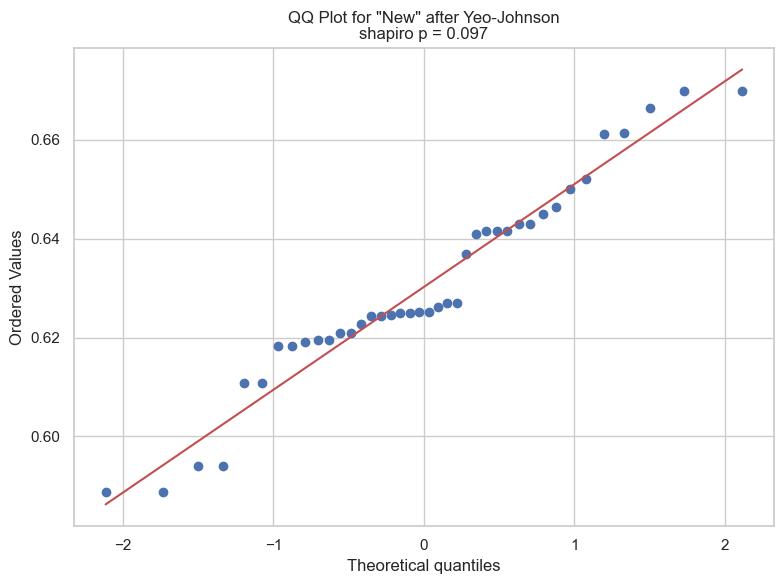

In [74]:

df_past["agility_transformed"] = Yeo_johnson(df_past, "agility", "Past")
df_new["agility_transformed"] = Yeo_johnson(df_new, "agility", "New")

In [75]:
t_test = stats.ttest_ind( df_new["agility_transformed"] , df_past["agility_transformed"],  equal_var=False, alternative='greater' )
print(f"T-statistic = {t_test.statistic:.3f}, p-value = {t_test.pvalue:.3f}")

T-statistic = -37.142, p-value = 1.000


فرضیه دوم

<ul dir="rtl" style="font-family: vazir; font-size: medium; line-height: 200%; text-align: justify;">
  <li><strong>فرضیه صفر (H<sub>0</sub>):</strong> میانگین توانایی ذاتی بازیکنان تیم قهرمان در دو فصل اخیر تفاوتی با دو فصل قبل ار آن ندارد</li>
  <li><strong>فرضیه جایگزین (H<sub>1</sub>):</strong>میانگین توانایی ذاتی بازیکنان تیم قهرمان در دو فصل اخیر بیشتر از دو فصل قبل از آن است</li></li>
</ul>


In [63]:
#فرضیه دوم
try:
    
    with mysql.connector.connect(**config) as cnxn:
        query_past_season = """
        select
            r.season,
            p.player_id,
            p.player_name,
            p.experience,
            p.age,
            (p.experience / p.age) as intrinsic_ability,
            'Past' as group_label
        from season_stats s
        join team_lookup t on s.champion_name = t.team_name
        join rosters r on r.team_id = t.team_id and r.season = s.season
        join players p on p.player_id = r.player_id
        where s.season in (2022, 2023) and p.experience is not null;
        
            """

        query_new_season = """
        select
            r.season,
            p.player_id,
            p.player_name,
            p.experience,
            p.age,
            (p.experience / p.age) as intrinsic_ability,
            'New' as group_label
        from season_stats s
        join team_lookup t on s.champion_name = t.team_name
        join rosters r on r.team_id = t.team_id and r.season = s.season
        join players p on p.player_id = r.player_id
        where s.season in (2024, 2025) and p.experience is not null;
     
            """
        df_past_season = pd.read_sql(query_past_season, cnxn)
        df_new_season = pd.read_sql(query_new_season, cnxn)
        
        display(df_past_season)
        display(df_new_season)
        
        dft2 = pd.concat([df_past_season, df_new_season], ignore_index=True)
        # display(dft1)

except mysql.connector.Error as err:
    print(f"❌ Error: {err}")


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_7520\2066598134.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_past_season = pd.read_sql(query_past_season, cnxn)
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_7520\2066598134.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_new_season = pd.read_sql(query_new_season, cnxn)


,season,player_id,player_name,experience,age,intrinsic_ability,group_label
0,2022,chiozch01,chris chiozza,4.0,30.0,0.133333,Past
1,2022,curryst01,stephen curry,16.0,37.0,0.432432,Past
2,2022,dowtije01,jeff dowtin jr.,4.0,28.0,0.142857,Past
3,2022,greendr01,draymond green,13.0,35.0,0.371429,Past
4,2022,kuminjo01,jonathan kuminga,4.0,23.0,0.173913,Past
5,2022,leeda03,damion lee,7.0,33.0,0.212121,Past
6,2022,looneke01,kevon looney,10.0,29.0,0.344828,Past
7,2022,moodymo01,moses moody,4.0,23.0,0.173913,Past
8,2022,paytoga02,gary payton ii,9.0,33.0,0.272727,Past
9,2022,poolejo01,jordan poole,6.0,26.0,0.230769,Past


,season,player_id,player_name,experience,age,intrinsic_ability,group_label
0,2024,bantoda01,dalano banton,4.0,26.0,0.153846,New
1,2024,brissos01,oshae brissett,6.0,27.0,0.222222,New
2,2024,brownja02,jaylen brown,9.0,29.0,0.310345,New
3,2024,davisjd01,jd davison,3.0,23.0,0.130435,New
4,2024,hausesa01,sam hauser,4.0,28.0,0.142857,New
5,2024,holidjr01,jrue holiday,16.0,35.0,0.457143,New
6,2024,horfoal01,al horford,18.0,39.0,0.461538,New
7,2024,kornelu01,luke kornet,8.0,30.0,0.266667,New
8,2024,mykhasv01,svi mykhailiuk,7.0,28.0,0.250000,New
9,2024,peterdr01,drew peterson,2.0,26.0,0.076923,New


c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


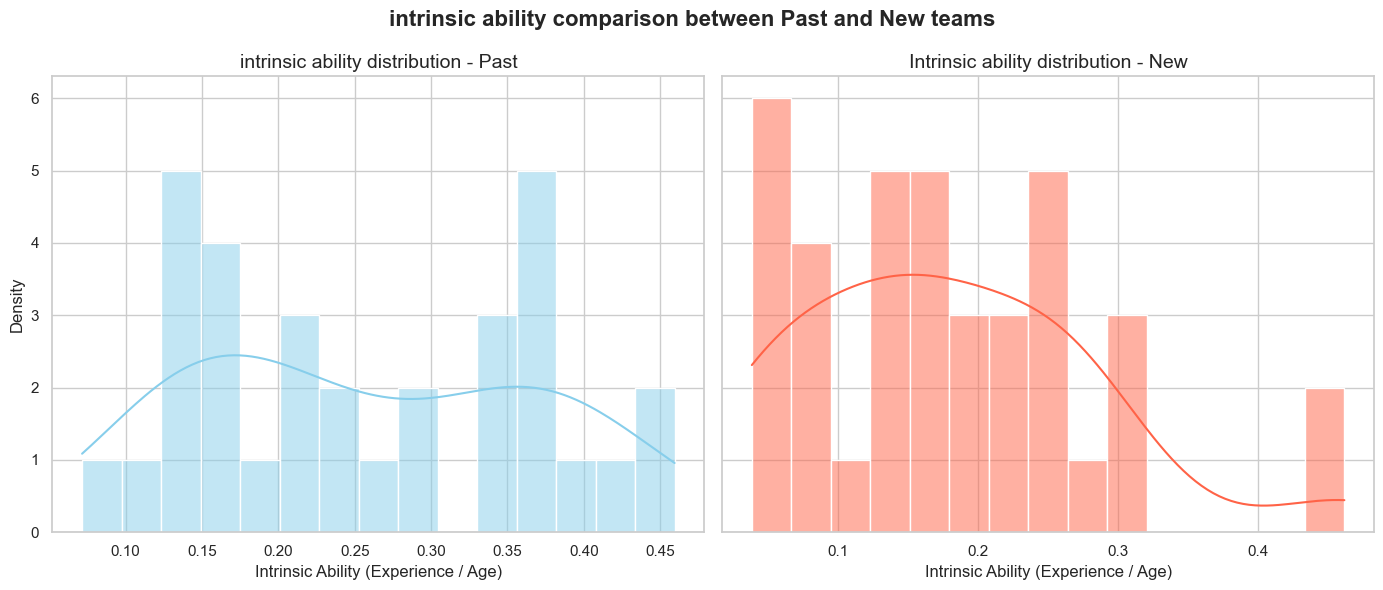

In [64]:
# هیستوگرام
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.histplot(data=df_past_season, x="intrinsic_ability", bins=15, kde=True, color="skyblue", ax=axes[0])
axes[0].set_title("intrinsic ability distribution - Past", fontsize=14)
axes[0].set_xlabel("Intrinsic Ability (Experience / Age)")
axes[0].set_ylabel("Density")

sns.histplot(data=df_new_season, x="intrinsic_ability", bins=15, kde=True, color="tomato", ax=axes[1])
axes[1].set_title("Intrinsic ability distribution - New", fontsize=14)
axes[1].set_xlabel("Intrinsic Ability (Experience / Age)")
axes[1].set_ylabel("Density")

plt.suptitle("intrinsic ability comparison between Past and New teams", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


In [65]:
#shapiro test
shapiro_past = stats.shapiro(df_past_season['intrinsic_ability'])
print(f"shapiro test (Past):")
print(f"statistic = {shapiro_past.statistic:.3f}, p-value = {shapiro_past.pvalue:.3f}")

shapiro_new = stats.shapiro(df_new_season['intrinsic_ability'])
print(f"shapiro test (New):")
print(f"statistic = {shapiro_new.statistic:.3f}, p-value = {shapiro_new.pvalue:.3f}")

shapiro test (Past):
statistic = 0.940, p-value = 0.073
shapiro test (New):
statistic = 0.930, p-value = 0.020


Yeo-Johnson transformation for Past:
λ = -0.589, shapiro p-value = 0.095


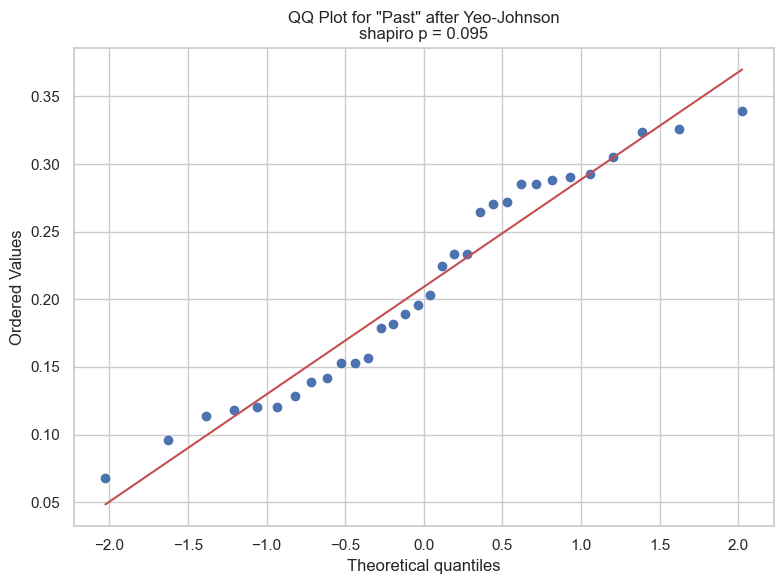

Yeo-Johnson transformation for New :
λ = -2.418, shapiro p-value = 0.152


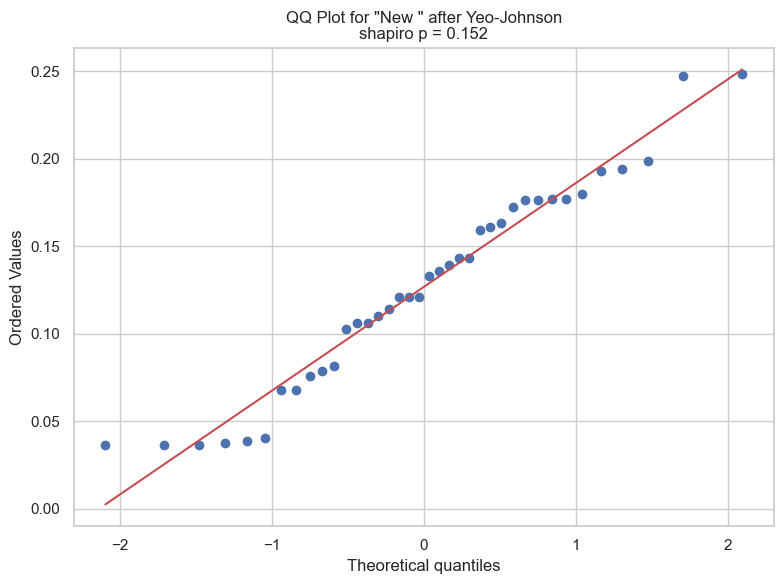

In [66]:
df_past_season["intrinsic_ability_transforme"] = Yeo_johnson(df_past_season, "intrinsic_ability", "Past")
df_new_season["intrinsic_ability_transforme"] = Yeo_johnson(df_new_season, "intrinsic_ability", "New ")


In [67]:
t_test = stats.ttest_ind( df_new_season["intrinsic_ability_transforme"] , df_past_season["intrinsic_ability_transforme"],  equal_var=False, alternative='greater' )
print(f"T-statistic = {t_test.statistic:.3f}, p-value = {t_test.pvalue:.3f}")

T-statistic = -4.918, p-value = 1.000
